# TSARA, Phase 6 — plume events

**A walkthrough you can run, change and try to break.** Every number and figure
below is produced by the package from data manufactured inside this notebook,
where every plume the generator injected is known. No real measurement is read,
and nothing needs mounting. Notebook `06b` runs the same stage on the campaign
archive.

---

## How to use this notebook

1. **Run everything once** (*Run All*, about a minute).
2. **Every section stands on its own.** Each opens with a **parameters cell**:
   a short list of CAPITALISED names, each commented with what it controls.
   Change a value, then run that section's cells from the parameters cell down
   to the next heading. Sections share only the two setup cells below.
3. **Every section prints checks.** A line beginning ✔ is a claim about TSARA,
   compared *as it ran* against something written independently in this
   notebook: a loop written from the definition, a closed form, or the
   generator's answer key. The checks are written to hold at *any* parameters.
   If you ever see ✘, you have found an edge case worth understanding or a bug.
4. **"Try it"** notes after each section suggest a change and say what should
   happen. Each prediction was run before this notebook was committed.
5. **Section 9** collects every check into one scoreboard and lists what is
   known to be imperfect.

---

## What this phase delivers

A plume only adds to the air, so an enhancement's readings below its most common
value are plume-free air. Phase 6 measures that air and finds events against it,
per variable, per stretch of record, at every point of the baseline's window ×
quantile sweep and of its own entry × exit thresholds (`METHODS.md` §6.8):

| | Property | Section |
|---|---|---|
| 1 | **Plume-free air is measured, not modelled**: its most common enhancement (the clean level) and 1.4826 × the median distance below it (the clean spread) | §1 |
| 2 | **Described one record at a time**: a stream split at long gaps and cut to a maximum length; a gap between readings is a dropout | §2 |
| 3 | **Events by two thresholds**: a run above the exit multiple that reaches the entry multiple, never across a dropout, short dips bridged | §3 |
| 4 | **Chance has a known rate**, recorded beside every sweep point's count | §4 |
| 5 | **The window decides what is a plume**, and a tree links each event to the one holding it at a longer window | §5 |
| 6 | **Scoring is a join** against the answer key | §6 |
| 7 | **A sparse canister takes its events** from a dense analyzer | §7 |
| 8 | **The state and the catalog save and reload exactly** | §8 |

What this phase does **not** do: fit ratios, combine uncertainties or build the
stability cube (Phase 7), or smooth and cluster (Phase 8). Nor does it
integrate plume areas (`METHODS.md` §7).

---

## Vocabulary used throughout

| term | meaning |
|---|---|
| **enhancement** Δ | reading minus its baseline at one window and quantile (Phase 5); negative in clean air, never clipped |
| **plume** | an enhancement in the air from an emission: what the generator injects and this stage looks for |
| **event** | an interval this stage reported on one variable at one sweep point. A plume, part of one, several merged, or a chance crossing |
| **record** | a stretch of one variable's readings, split where two are more than a gap apart and cut to a maximum length; plume-free air is described per record |
| **clean level** *m* | the most common enhancement of a record at a sweep point: its half-sample mode |
| **clean spread** *s* | 1.4826 × the median distance below the clean level. *Not* a measurement uncertainty: it holds the background's wobble at the window's scale |
| ***z*** | (Δ − *m*) / *s*: how many clean spreads a reading stands above plume-free air |
| **entry, exit multiple** | an event holds a reading with *z* ≥ entry and runs while *z* ≥ exit |
| **dropout** | two readings of a record more than 1.5 × its median spacing apart; an event never runs across one |
| **sweep point** | one (window, quantile, entry, exit) combination; every one is computed |
| **trigger** | the variable a sparse one takes its events from |
| **source** | an *emission* source only: a landfill, a gas line |

---
## Setup (run these two cells first)

The first cell is the **toolkit**: imports, the figure style shared by notebooks
01–06, helpers, the **reference implementations** every check compares TSARA
against, and the scoreboard. The second holds the **campaign recipes**, one
function per synthetic campaign, whose keyword arguments are the knobs.

In [1]:
# =============================================================================
# TOOLKIT. Every section needs this cell and nothing else from other sections.
# =============================================================================
import logging
import tempfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

from tsara import setup_logging
from tsara.baseline import baseline_state
from tsara.config.analysis import BaselineConfig, PlumesConfig
from tsara.config.loader import load_synthetic
from tsara.config.synthetic import SyntheticConfig
from tsara.core.support import CellBounds, stream_cells
from tsara.plumes import (
    CATALOG_COLUMNS,
    expected_chance_rate,
    find_events,
    find_records,
    load_plumes,
    plume_catalog,
    plume_state,
    plume_states,
    save_plumes,
)
from tsara.synthetic import generate
from tsara.synthetic.plumes import GROUND_TRUTH_COLUMNS

SECOND = 1_000_000_000  # TSARA keeps every time as integer nanoseconds
HOUR = 3600 * SECOND
# The shipped example configurations, from the notebook's folder or the repo root.
CONFIGS = next(p for p in (Path("../configs"), Path("examples/configs")) if p.is_dir())

# --- 1. figure style (identical to notebooks 01-05) --------------------------
C1, C2, C3 = "#0072b2", "#e69f00", "#009e73"  # Okabe-Ito blue, amber, green: colour-blind safe
C4 = "#cc79a7"  # Okabe-Ito purple, for a fourth series
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def break_gaps(clock, values, tolerance=5.0):
    """Insert a NaN wherever the clock jumps, so matplotlib draws no line across a gap.

    A plotted line is a straight segment between neighbouring points, so a hole
    in a record would otherwise render as a smooth ramp across it: exactly the
    interpolation TSARA refuses to perform on a gas.
    """
    clock, values = np.asarray(clock), np.asarray(values, dtype=float)
    steps = np.diff(clock).astype("timedelta64[ms]").astype(float)
    gaps = np.where(steps > tolerance * np.median(steps))[0]
    if gaps.size == 0:
        return clock, values
    return np.insert(clock, gaps + 1, clock[gaps]), np.insert(values, gaps + 1, np.nan)


def shade_events(ax, cells, membership, color=C2, alpha=0.25):
    """Shade each event's interval, first cell start to last cell stop."""
    for k in np.unique(membership[membership >= 0]):
        rows = np.flatnonzero(membership == k)
        ax.axvspan(
            pd.Timestamp(int(cells.start_ns[rows[0]])),
            pd.Timestamp(int(cells.stop_ns[rows[-1]])),
            color=color,
            alpha=alpha,
            lw=0,
        )


# --- 2. streams and arrays ----------------------------------------------------
def same(a, b):
    """Equal arrays, blanks in the same places counting as equal."""
    a, b = np.asarray(a), np.asarray(b)
    if a.dtype.kind in "fc" or b.dtype.kind in "fc":
        return a.shape == b.shape and bool(np.array_equal(a, b, equal_nan=True))
    return bool(np.array_equal(a, b))


def measured(stream):
    """Drop the generator's answer-key columns (`truth_*`), keeping what an instrument reports."""
    return stream.drop_vars([v for v in stream.data_vars if str(v).startswith("truth_")])


def sweep(windows=("2min", "10min", "60min"), quantiles=(0.05,), **more):
    """Return a BaselineConfig for a sweep."""
    return BaselineConfig.model_validate(
        {"windows": list(windows), "quantiles": list(quantiles), **more}
    )


def thresholds(enter=(3.0,), exit_=(1.0,), **more):
    """Return a PlumesConfig: entry and exit multiples plus any other setting."""
    return PlumesConfig.model_validate(
        {"enter_multiple": list(enter), "exit_multiple": list(exit_), **more}
    )


# --- 3. reference implementations --------------------------------------------
# Written from the definitions in METHODS §6.8, deliberately slow and plain. They
# share no code with TSARA: no vectorized search, no sort carried between steps.
# If TSARA and these agree, it is because both compute the definition.


def reference_half_sample_mode(values):
    """Bickel and Fruhwirth (2006), one interval at a time.

    Sort; keep the shortest interval holding ceil(n/2) of the values (the earliest
    on a tie); repeat until three or fewer remain; of three, the mean of the closer
    pair, or the middle one when the gaps are equal; of two, their mean.
    """
    x = sorted(v for v in values if np.isfinite(v))
    while len(x) > 3:
        half = -(-len(x) // 2)
        best, width = 0, np.inf
        for j in range(len(x) - half + 1):
            if x[j + half - 1] - x[j] < width:
                best, width = j, x[j + half - 1] - x[j]
        x = x[best : best + half]
    if len(x) < 3:
        return float(np.mean(x))
    if x[1] - x[0] < x[2] - x[1]:
        return (x[0] + x[1]) / 2
    if x[1] - x[0] > x[2] - x[1]:
        return (x[1] + x[2]) / 2
    return x[1]


def reference_clean(values):
    """Return the clean level and spread of one record at one sweep point, by definition."""
    level = reference_half_sample_mode(values)
    below = [level - v for v in values if np.isfinite(v) and v < level]
    return level, 1.4826 * float(np.median(below))


def shortest_half_midpoint(values):
    """Return the midpoint of the shortest half: the estimator withdrawn on 2026-09-29."""
    x = np.sort(np.asarray(values)[np.isfinite(values)])
    half = (x.size + 1) // 2
    start = int(np.argmin(x[half - 1 :] - x[: x.size - half + 1]))
    return float((x[start] + x[start + half - 1]) / 2)


def reference_events(z, cells, dropout_before, record, enter, exit_, gap_ns):
    """Events one reading at a time, from METHODS §6.8's paragraph.

    Walk the finite readings in order. A run continues while z >= exit; a record
    change, a dropout or a blank reading ends it; a dip below exit is bridged when
    the time from the last run reading's cell stop to the next above-exit reading's
    cell start is shorter than the gap (zero where cells overlap); a run that ever
    reaches entry is an event. Returns each reading's event number, -1 for none.
    """
    membership = np.full(len(z), -1)
    events, current, dip, previous = [], [], [], None

    def close():
        if current and max(z[i] for i in current) >= enter:
            events.append(list(current))

    for i in range(len(z)):
        if record[i] < 0:
            continue
        broken = (
            previous is None
            or record[i] != record[previous]
            or dropout_before[i]
            or np.isnan(z[i])
            or np.isnan(z[previous])
        )
        previous = i
        if broken:
            close()
            current, dip = [], []
        if np.isnan(z[i]):
            continue
        if z[i] >= exit_:
            if current and dip and max(cells.start_ns[i] - cells.stop_ns[current[-1]], 0) >= gap_ns:
                close()
                current, dip = [], []
            current = current + dip + [i]
            dip = []
        elif current:
            dip.append(i)
    close()
    for number, rows in enumerate(events):
        membership[rows] = number
    return membership


def reference_records(midpoints_ns, finite, gap_ns, max_ns):
    """Find records one reading at a time, from METHODS §6.8, part edges as exact fractions.

    A piece ends where two consecutive finite readings are more than the gap apart.
    A piece spanning more than the maximum is cut into n equal parts, n the fewest
    that keep each part no longer than the maximum; a reading goes to the part its
    midpoint falls in, the last reading to the last part. Empty parts are dropped.
    """
    from fractions import Fraction

    kept = [i for i in range(len(midpoints_ns)) if finite[i]]
    pieces = []
    for i in kept:
        if pieces and int(midpoints_ns[i]) - int(midpoints_ns[pieces[-1][-1]]) <= gap_ns:
            pieces[-1].append(i)
        else:
            pieces.append([i])
    out, record = np.full(len(midpoints_ns), -1), 0
    for piece in pieces:
        first = int(midpoints_ns[piece[0]])
        span = int(midpoints_ns[piece[-1]]) - first
        n = 1
        while Fraction(span, n) > max_ns:
            n += 1
        parts = {}
        for i in piece:
            k = min(int(Fraction(int(midpoints_ns[i]) - first) * n / span) if span else 0, n - 1)
            parts.setdefault(k, len(parts))
            out[i] = record + parts[k]
        record += len(parts)
    return out


def chance_rate(enter, exit_):
    """Events per reading on independent Gaussian readings: the closed form, written out.

    A reading opens a run above exit with probability (1 - p_x) p_x; the run is
    geometric; each reading in it reaches entry with probability p_e / p_x.
    """
    p_x, p_e = norm.sf(exit_), norm.sf(enter)
    return (1 - p_x) * (p_x - (1 - p_x) * (p_x - p_e) / (1 - p_x + p_e))


# --- 4. the scoreboard -------------------------------------------------------
CHECKS = {}  # claim -> (held?, detail); section 9 prints them all


def start_section(tag):
    """Forget a section's earlier checks, so re-running it replaces rather than piles up."""
    for claim in [c for c in CHECKS if c.startswith(tag + " ")]:
        del CHECKS[claim]


def check(claim, holds, detail=""):
    """Record one claim about TSARA and print whether it held just now."""
    CHECKS[claim] = (bool(holds), detail)
    mark = "✔" if holds else "✘ DOES NOT HOLD:"
    print(f"  {mark} {claim}" + (f"   [{detail}]" if detail else ""))


# --- 5. logging, and a scratch directory --------------------------------------
_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)  # the bundle section writes here


def scrub_work_dir(record):
    """Show the scratch directory as <work> in TSARA's log messages."""
    if isinstance(record.msg, str):
        record.msg = record.msg.replace(str(WORK), "<work>")
    if isinstance(record.args, tuple):
        record.args = tuple(
            str(a).replace(str(WORK), "<work>") if str(WORK) in str(a) else a for a in record.args
        )
    return True


for handler in setup_logging(logging.WARNING).handlers:
    handler.addFilter(scrub_work_dir)

print("toolkit ready")

toolkit ready


In [2]:
# =============================================================================
# CAMPAIGN RECIPES. Each builds one synthetic campaign with the generator from
# notebook 01, which records the truth it used: the plume-free background under
# every reading and every plume it injected (the answer key). Each keyword is a
# knob; its default is what the section introducing the campaign uses.
# =============================================================================


def _field(offset, units="ppb", **background):
    """Return one atmosphere field: a gas at plume-free level `offset`, plus optional terms."""
    return {
        "role": "gas",
        "units": units,
        "background": {"kind": "parametric", "offset": offset, **background},
    }


def _measure(noise, name=None):
    """Return how an instrument measures a field: its 1-sigma noise, and its own name."""
    spec = {"uncertainty": {"random": {"absolute": noise}}}
    if name:
        spec["name"] = name
    return spec


def landfill_campaign(
    *,
    seed=5,
    duration="6h",
    noise_ppb=0.7,
    landfill_per_hour=0.6,
    landfill_sigma="8min",
    landfill_median_ppb=60.0,
    blips_per_hour=10.0,
    blip_median_ppb=120.0,
    random_walk_ppb_per_day=0.0,
):
    """Build METHODS §6.1's worked case: broad landfill plumes with short gas blips on top.

    One methane field at 1900 ppb seen by one 1 s analyzer (`analyzer`) with
    `noise_ppb` of white noise. Two emitters: a landfill whose plumes last tens
    of minutes, and a gas line whose blips last seconds (EMG, 6 s / 12 s).
    """
    sources = {}
    if landfill_per_hour:
        sources["landfill"] = {
            "rate_per_hour": landfill_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "gaussian", "sigma": landfill_sigma},
            "amplitude": {"kind": "lognormal", "median": landfill_median_ppb, "sigma_log": 0.3},
        }
    if blips_per_hour:
        sources["gas_line"] = {
            "rate_per_hour": blips_per_hour,
            "reference_species": "ch4",
            "shape": {"kind": "emg", "sigma": "6s", "tau": "12s"},
            "amplitude": {"kind": "lognormal", "median": blip_median_ppb, "sigma_log": 0.4},
        }
    background = {"random_walk_std": random_walk_ppb_per_day} if random_walk_ppb_per_day else {}
    description = {
        "name": "landfill_demo",
        "seed": seed,
        "start": "2026-06-15T10:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "truth_resolution": "1s",
            "fields": {"ch4": _field(1900.0, **background)},
            "sources": sources,
        },
        "instruments": {
            "analyzer": {"native_rate": "1s", "measures": {"ch4": _measure(noise_ppb)}}
        },
    }
    return generate(SyntheticConfig.model_validate(description))


def canister_campaign(*, seed=21, duration="6h", fill_every="300s", plumes_per_hour=3.0):
    """Build a whole-air canister sampler beside a dense benzene analyzer.

    `ptr`  measures benzene every second with 0.02 ppb of noise.
    `iwas` measures benzene in canisters, each the mean over a 15 s fill,
           roughly every `fill_every`.
    A refinery's plumes (Gaussian, 3 min) cross both.
    """
    cadence_s = pd.Timedelta(fill_every).total_seconds()
    description = {
        "name": "canister_demo",
        "seed": seed,
        "start": "2026-06-16T15:00:00Z",
        "duration": duration,
        "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
        "atmosphere": {
            "fields": {"benzene": _field(0.5)},
            "sources": {
                "refinery": {
                    "rate_per_hour": plumes_per_hour,
                    "reference_species": "benzene",
                    "shape": {"kind": "gaussian", "sigma": "3min"},
                    "amplitude": {"kind": "lognormal", "median": 1.5, "sigma_log": 0.5},
                }
            },
        },
        "instruments": {
            "ptr": {"native_rate": "1s", "measures": {"benzene": _measure(0.02)}},
            "iwas": {
                "native_rate": fill_every,
                "timestamp_jitter": f"{min(60.0, 0.45 * cadence_s):g}s",
                "support": {"method": "mean", "width": "15s"},
                "measures": {"benzene": _measure(0.01, name="benzene_can")},
            },
        },
    }
    return generate(SyntheticConfig.model_validate(description))


print("recipes ready")

recipes ready


---
## 1. What plume-free air looks like, measured

**The question.** An event is an enhancement standing out from plume-free air,
so plume-free air has to be described first: where it sits and how much it
wobbles. Phase 5's baseline is a low quantile, which sits *below* the air's
typical level by an amount that depends on the window, so the enhancement of
clean air is not centred on zero. Rather than model that offset, TSARA measures
it (`METHODS.md` §6.8): plumes only add, so the readings below the enhancement's
most common value are plume-free air.

- the **clean level** *m* is that most common value, found by the half-sample
  mode (`half_sample_mode` in `src/tsara/plumes/clean.py`);
- the **clean spread** *s* is 1.4826 × the median distance below *m*
  (`describe_clean_air`, same file);
- a reading's ***z*** = (Δ − *m*) / *s*.

The campaign is §6.1's landfill with gas blips, where 40–50 % of readings sit in
a plume. The generator knows which readings are truly plume-free, so the check
is direct: *m* and *s* against the median and 1.4826 × MAD of the enhancement
over the readings whose true plume contribution is under 0.1 σ.

In [3]:
# ---- PARAMETERS (section 1) --------------------------------------------------
WINDOW = "10min"  # the baseline window whose enhancement is described
QUANTILE = 0.05  # the baseline's quantile
LANDFILL_PER_HOUR = 0.6  # broad landfill plumes an hour (sigma 8 min)
BLIPS_PER_HOUR = 10.0  # short gas blips an hour
SEED = 5

In [4]:
start_section("§1")
campaign = landfill_campaign(
    seed=SEED, landfill_per_hour=LANDFILL_PER_HOUR, blips_per_hour=BLIPS_PER_HOUR
)
stream = campaign.observable("analyzer")  # what the instrument reported, no truth
state = baseline_state(
    stream, instrument="analyzer", baseline=sweep(windows=(WINDOW,), quantiles=(QUANTILE,))
)
found = plume_state(state, instrument="analyzer", plumes=thresholds())
delta = state["enhancement_ch4"].values[:, 0, 0]
level = float(found["clean_level_ch4"].values[0, 0, 0])
spread = float(found["clean_spread_ch4"].values[0, 0, 0])

# The truth: the enhancement over the readings the generator says are plume-free.
sigma = 0.7
true_plume = campaign.streams["analyzer"]["truth_enhancement_ch4"].values
clean = (true_plume < 0.1 * sigma) & np.isfinite(delta)
true_level = float(np.median(delta[clean]))
true_spread = 1.4826 * float(np.median(np.abs(delta[clean] - true_level)))
by_hand_level, by_hand_spread = reference_clean(list(delta))
withdrawn = shortest_half_midpoint(delta)

in_plume = np.mean(true_plume > 3 * sigma)
print(f"readings: {delta.size}, of which in a plume above 3 sigma: {in_plume:.0%}")
print(f"records: {int(found['record_ch4'].max()) + 1}")
print(f"{'':30s} {'level (ppb)':>12s} {'spread (ppb)':>13s}")
print(f"{'TSARA':30s} {level:12.3f} {spread:13.3f}")
print(f"{'the definition, by hand':30s} {by_hand_level:12.3f} {by_hand_spread:13.3f}")
print(f"{'truth (plume-free readings)':30s} {true_level:12.3f} {true_spread:13.3f}")
print(
    f"error in true spreads: TSARA {(level - true_level) / true_spread:+.2f}; "
    f"midpoint of the shortest half (withdrawn) {(withdrawn - true_level) / true_spread:+.2f}"
)
check("§1 the clean level is the half-sample mode, as the paper defines it", level == by_hand_level)
check("§1 the clean spread is 1.4826 x the median distance below it", spread == by_hand_spread)
check(
    "§1 the clean level lies within one true spread of truly plume-free air",
    abs(level - true_level) < true_spread,
    f"{(level - true_level) / true_spread:+.2f} true spreads",
)
check(
    "§1 the clean spread is within a factor of two of the true one",
    0.5 < spread / true_spread < 2.0,
    f"{spread / true_spread:.2f}",
)

readings: 21600, of which in a plume above 3 sigma: 41%
records: 1
                                level (ppb)  spread (ppb)
TSARA                                 1.160         0.745
the definition, by hand               1.160         0.745
truth (plume-free readings)           1.060         0.695
error in true spreads: TSARA +0.14; midpoint of the shortest half (withdrawn) +0.06
  ✔ §1 the clean level is the half-sample mode, as the paper defines it
  ✔ §1 the clean spread is 1.4826 x the median distance below it
  ✔ §1 the clean level lies within one true spread of truly plume-free air   [+0.14 true spreads]
  ✔ §1 the clean spread is within a factor of two of the true one   [1.07]


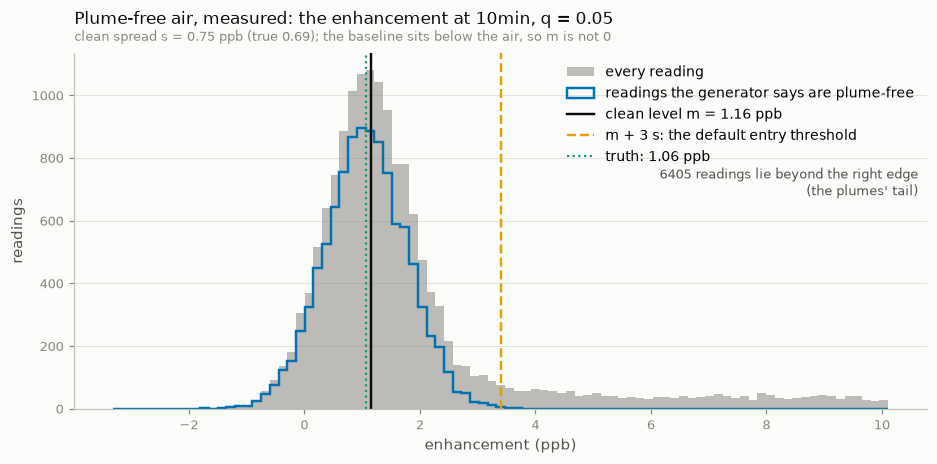

In [5]:
# Figure only: the enhancement's histogram near the clean level, with the truth beside it.
low, high = level - 6 * spread, level + 12 * spread
bins = np.linspace(low, high, 90)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.hist(delta[np.isfinite(delta)], bins=bins, color=MUTED, alpha=0.55, label="every reading")
ax.hist(
    delta[clean],
    bins=bins,
    histtype="step",
    color=C1,
    lw=1.6,
    label="readings the generator says are plume-free",
)
ax.axvline(level, color=INK, lw=1.6, label=f"clean level m = {level:.2f} ppb")
ax.axvline(
    level + 3 * spread, color=C2, lw=1.6, ls="--", label="m + 3 s: the default entry threshold"
)
ax.axvline(true_level, color=C3, lw=1.4, ls=":", label=f"truth: {true_level:.2f} ppb")
beyond = int(np.sum(delta > high))
ax.text(
    0.99,
    0.60,
    f"{beyond} readings lie beyond the right edge\n(the plumes' tail)",
    transform=ax.transAxes,
    ha="right",
    fontsize=8.5,
    color=INK2,
)
finish(
    ax,
    f"Plume-free air, measured: the enhancement at {WINDOW}, q = {QUANTILE}",
    f"clean spread s = {spread:.2f} ppb (true {true_spread:.2f}); "
    "the baseline sits below the air, so m is not 0",
    "readings",
    "enhancement (ppb)",
    legend=True,
    loc="upper right",
)
plt.show()

The grey bars are every reading's enhancement and the blue outline is the ones
the generator says are plume-free: the plumes fill the long right tail, and the
peak on the left is clean air. The clean level sits on that peak, and the spread
is read off its left side only, where no plume can reach. The level is not zero
because a 5th-percentile baseline sits below the air's typical value.

**Try it.**
- `LANDFILL_PER_HOUR = 1.5` and `BLIPS_PER_HOUR = 40` make §6.8's *dense* record,
  where most readings sit in a plume. TSARA's level stays within about a third of
  a true spread of the truth, while the withdrawn midpoint of the shortest half,
  printed beside it, is off by several. That collapse is why it was withdrawn.
- `QUANTILE = 0.01`: the level rises from about 1.2 to 1.5 ppb. In plume-free
  air a 1st percentile sits about 2.3 σ below the air's typical value and a 5th
  about 1.6 σ, with σ 0.7 ppb here; the level measures that offset rather than
  assuming it.

---
## 2. Records: plume-free air is described one stretch at a time

**The question.** Over days of a ground site, or a van that logs parked and
driving alike, one level and one spread would mix air that was never the same.
So each variable's finite readings are split into **records**: a new record
starts where two readings are more than `record_gap` apart (default 2 h), and a
piece longer than `max_record_length` (default 6 h) is cut into the fewest equal
parts no longer than it (`find_records` in `src/tsara/plumes/records.py`).

A record also fixes what a **dropout** is: two consecutive finite readings more
than 1.5 × the record's median spacing apart. An event never runs across one,
because missing data is not turbulent air.

The stream here is twenty hours of 1 s cells with two holes: a three-hour
outage and one missing reading.

In [6]:
# ---- PARAMETERS (section 2) --------------------------------------------------
HOURS = 20  # length of the stream (1 s cells)
OUTAGE = (6.0, 9.0)  # hours into the stream: nothing is recorded
MISSING_AT = 12.0  # hours into the stream: one reading is missing
RECORD_GAP = "2h"
MAX_RECORD_LENGTH = "6h"

In [7]:
start_section("§2")
start = pd.Timestamp("2026-06-15T00:00:00").value
starts = start + np.arange(HOURS * 3600, dtype=np.int64) * SECOND
cells = CellBounds(start_ns=starts, stop_ns=starts + SECOND)
hours = (starts - start) / HOUR
finite = ~((hours >= OUTAGE[0]) & (hours < OUTAGE[1]))
missing = int(np.argmin(np.abs(hours - MISSING_AT)))
finite[missing] = False

records = find_records(
    cells,
    finite,
    gap_ns=pd.Timedelta(RECORD_GAP).value,
    max_length_ns=pd.Timedelta(MAX_RECORD_LENGTH).value,
)
print(
    f"{'record':>6} {'from (h)':>9} {'to (h)':>7} {'hours':>6} {'readings':>9} "
    f"{'median spacing':>15}"
)
for r in range(records.n):
    rows = records.index == r
    print(
        f"{r:>6} {(records.start_ns[r] - start) / HOUR:>9.2f} "
        f"{(records.stop_ns[r] - start) / HOUR:>7.2f} "
        f"{(records.stop_ns[r] - records.start_ns[r]) / HOUR:>6.2f} {rows.sum():>9} "
        f"{records.median_spacing_ns[r] / SECOND:>13.1f} s"
    )
dropouts = hours[records.dropout_before]
print(f"dropouts (hours into the stream): {[round(float(h), 3) for h in dropouts]}")

by_hand = reference_records(
    cells.midpoint_ns, finite, pd.Timedelta(RECORD_GAP).value, pd.Timedelta(MAX_RECORD_LENGTH).value
)
check(
    "§2 every reading's record is the definition's, reading by reading",
    np.array_equal(records.index, by_hand),
)
check(
    "§2 no record is longer than the maximum length",
    np.all(records.stop_ns - records.start_ns <= pd.Timedelta(MAX_RECORD_LENGTH).value + SECOND),
)
check(
    "§2 no record spans a gap longer than the record gap",
    all(
        np.all(np.diff(cells.midpoint_ns[records.index == r]) <= pd.Timedelta(RECORD_GAP).value)
        for r in range(records.n)
    ),
)
# Dropouts from the definition, one step at a time: a step between consecutive
# finite readings of one record longer than 1.5 x that record's median step. A
# step across a record's edge is none: the edge already breaks any event.
kept = np.flatnonzero(finite)
steps_of = {}
for a, b in zip(kept[:-1], kept[1:]):
    if by_hand[a] == by_hand[b]:
        steps_of.setdefault(by_hand[a], []).append(
            (b, int(cells.midpoint_ns[b] - cells.midpoint_ns[a]))
        )
hand_dropouts = []
for steps in steps_of.values():
    typical = np.median([step for _, step in steps])
    hand_dropouts += [b for b, step in steps if step > 1.5 * typical]
hand_dropouts.sort()
check(
    "§2 the dropouts are the definition's: steps within a record over 1.5 x its median step",
    np.array_equal(np.flatnonzero(records.dropout_before), hand_dropouts),
    f"{len(hand_dropouts)} found",
)

record  from (h)  to (h)  hours  readings  median spacing
     0      0.00    6.00   6.00     21600           1.0 s
     1      9.00   14.50   5.50     19799           1.0 s
     2     14.50   20.00   5.50     19800           1.0 s
dropouts (hours into the stream): [12.0]


  ✔ §2 every reading's record is the definition's, reading by reading
  ✔ §2 no record is longer than the maximum length
  ✔ §2 no record spans a gap longer than the record gap


  ✔ §2 the dropouts are the definition's: steps within a record over 1.5 x its median step   [1 found]


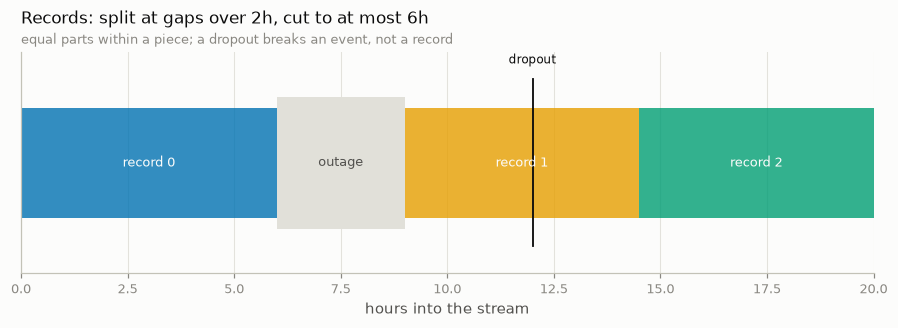

In [8]:
# Figure only: the stream's timeline, each record in its own colour, the holes marked.
fig, ax = plt.subplots(figsize=(10, 2.6))
palette = [C1, C2, C3, C4]
for r in range(records.n):
    ax.axvspan(
        (records.start_ns[r] - start) / HOUR,
        (records.stop_ns[r] - start) / HOUR,
        ymin=0.25,
        ymax=0.75,
        color=palette[r % 4],
        alpha=0.8,
        lw=0,
    )
    ax.text(
        ((records.start_ns[r] + records.stop_ns[r]) / 2 - start) / HOUR,
        0.5,
        f"record {r}",
        ha="center",
        va="center",
        fontsize=8.5,
        color=SURFACE,
    )
ax.axvspan(*OUTAGE, ymin=0.2, ymax=0.8, color=GRID, lw=0)
ax.text(np.mean(OUTAGE), 0.5, "outage", ha="center", va="center", fontsize=8.5, color=INK2)
for h in dropouts:
    ax.plot([h, h], [0.12, 0.88], color=INK, lw=1.2)
if dropouts.size:
    ax.text(MISSING_AT, 0.95, "dropout", ha="center", fontsize=8, color=INK)
ax.set_xlim(0, HOURS)
ax.set_ylim(0, 1)
ax.set_yticks([])
finish(
    ax,
    f"Records: split at gaps over {RECORD_GAP}, cut to at most {MAX_RECORD_LENGTH}",
    "equal parts within a piece; a dropout breaks an event, not a record",
    None,
    "hours into the stream",
    grid_axis="x",
)
plt.show()

The outage splits the stream in two, and each piece is then cut into equal parts
no longer than six hours: 6 h exactly before the outage, and two parts of 5.5 h
after it. The single missing reading is a dropout, because its neighbours are 2 s
apart against the record's median of 1 s. The rule reads the record's own median,
so an analyzer that reports every 2 or 3 s throughout (the 2024 Picarro, median
2 s) is not full of dropouts: only a step longer than 3 s would be one.

**Try it.**
- `MAX_RECORD_LENGTH = "3h"`: two parts before the outage and four after it.
- `MISSING_AT = 14.5`: the missing reading falls exactly on the cut between the
  two parts after the outage, so it is no dropout: the record's edge already
  breaks any event there.
- `RECORD_GAP = "4h"`: the three-hour outage no longer splits anything, so the
  whole twenty hours is one piece, cut into four equal parts of five hours, and
  the outage, now inside a record, is a dropout too: no event runs across it.

---
## 3. The detector: two thresholds, short dips bridged, dropouts never crossed

**The question.** Given *z* at every reading, where are the events? An event is a
run of readings with *z* ≥ exit that holds at least one with *z* ≥ entry
(`find_events` in `src/tsara/plumes/hysteresis.py`). Two thresholds rather than
one keep a plume hovering near one threshold from being chopped into fragments.
A dip below exit shorter than `max_internal_gap` is bridged, a dropout or a
blank reading never is, and there is no minimum duration: width cannot tell a
chance crossing from a narrow plume (`METHODS.md` §9.5, §6.8).

Below, the landfill campaign's methane at a 2 min window, a stretch with blips
in it, and the events drawn over *z*. The check compares every reading's event
against a loop written from the paragraph above.

In [9]:
# ---- PARAMETERS (section 3) --------------------------------------------------
ENTER = 3.0  # entry multiple
EXIT = 1.0  # exit multiple (must be below ENTER)
MAX_INTERNAL_GAP = "5s"  # dips below exit shorter than this are bridged
WINDOW = "2min"
ZOOM = (95, 110)  # minutes into the record to draw
SEED = 5

In [10]:
start_section("§3")
campaign = landfill_campaign(seed=SEED, duration="3h")
state = baseline_state(
    campaign.observable("analyzer"), instrument="analyzer", baseline=sweep(windows=(WINDOW,))
)
config = thresholds((ENTER,), (EXIT,), max_internal_gap=MAX_INTERNAL_GAP)
found = plume_state(state, instrument="analyzer", plumes=config)
z = found["z_ch4"].values[:, 0, 0]
membership = found["event_ch4"].values[:, 0, 0, 0, 0]
cells = stream_cells(state, "analyzer")
records = find_records(
    cells, np.isfinite(state["ch4"].values), gap_ns=2 * HOUR, max_length_ns=6 * HOUR
)
by_hand = reference_events(
    z,
    cells,
    records.dropout_before,
    records.index,
    ENTER,
    EXIT,
    pd.Timedelta(MAX_INTERNAL_GAP).value,
)
events = int(found["n_events_ch4"].values[0, 0, 0, 0])
print(f"events at entry {ENTER}, exit {EXIT}, gap {MAX_INTERNAL_GAP}: {events}")

# How well this record's plume-free air is described. The answer key says which
# readings are plume-free (true plume under 0.1 sigma); there z should reach entry
# as often as noise described correctly does, norm.sf(ENTER).
delta = state["enhancement_ch4"].values[:, 0, 0]
plume_free = (campaign.streams["analyzer"]["truth_enhancement_ch4"].values < 0.07) & np.isfinite(z)
true_level = float(np.median(delta[plume_free]))
true_spread = 1.4826 * float(np.median(np.abs(delta[plume_free] - true_level)))
level = float(found["clean_level_ch4"].values[0, 0, 0])
spread = float(found["clean_spread_ch4"].values[0, 0, 0])
crossing = float(np.mean(z[plume_free] >= ENTER))
print(
    f"plume-free: {plume_free.mean():.0%} of readings. Clean level off by "
    f"{(level - true_level) / true_spread:+.2f} true spreads, spread {spread / true_spread:.2f} x "
    f"the true one; z reaches entry at {crossing:.2%} of them, "
    f"{crossing / norm.sf(ENTER):.1f} x the rate for noise described correctly"
)
check(
    "§3 every reading's event is the one a loop over the definition finds",
    np.array_equal(membership, by_hand),
)
check(
    "§3 every event holds a reading at or above entry",
    all(np.nanmax(z[membership == k]) >= ENTER for k in range(events)),
)
gap_ns = pd.Timedelta(MAX_INTERNAL_GAP).value
dips_ok = True
for k in range(events):
    rows = np.flatnonzero(membership == k)
    above = rows[z[rows] >= EXIT]
    for i in rows[z[rows] < EXIT]:  # a member below exit must sit in a dip shorter than the gap
        before, after = above[above < i].max(), above[above > i].min()
        dips_ok &= max(cells.start_ns[after] - cells.stop_ns[before], 0) < gap_ns
check("§3 a reading below exit is in an event only inside a dip shorter than the gap", dips_ok)

events at entry 3.0, exit 1.0, gap 5s: 78
plume-free: 32% of readings. Clean level off by -0.36 true spreads, spread 0.87 x the true one; z reaches entry at 1.23% of them, 9.1 x the rate for noise described correctly
  ✔ §3 every reading's event is the one a loop over the definition finds
  ✔ §3 every event holds a reading at or above entry
  ✔ §3 a reading below exit is in an event only inside a dip shorter than the gap


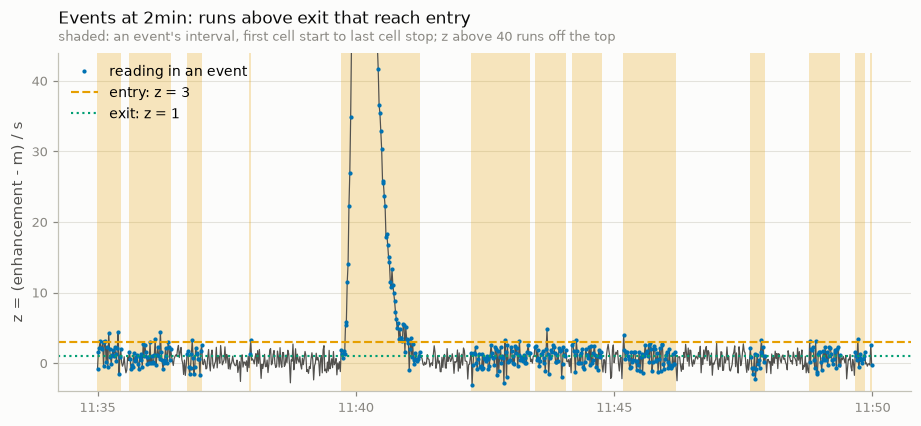

In [11]:
# Figure only: z over the zoomed stretch, the thresholds, and the events shaded.
t = found["time"].values
lo = t[0] + np.timedelta64(ZOOM[0], "m")
hi = t[0] + np.timedelta64(ZOOM[1], "m")
inside = (t >= lo) & (t < hi)
fig, ax = plt.subplots(figsize=(10, 4.0))
shade_events(ax, cells, np.where(inside, membership, -1))
ax.plot(t[inside], z[inside], color=INK2, lw=0.8)
member = inside & (membership >= 0)
ax.plot(t[member], z[member], ".", color=C1, ms=3.5, label="reading in an event")
ax.axhline(ENTER, color=C2, lw=1.4, ls="--", label=f"entry: z = {ENTER:g}")
ax.axhline(EXIT, color=C3, lw=1.4, ls=":", label=f"exit: z = {EXIT:g}")
top = min(float(np.nanmax(z[inside])), 40.0)
ax.set_ylim(-4, top * 1.1)
hhmm(ax)
finish(
    ax,
    f"Events at {WINDOW}: runs above exit that reach entry",
    f"shaded: an event's interval, first cell start to last cell stop; "
    f"z above {top:.0f} runs off the top",
    "z = (enhancement - m) / s",
    legend=True,
    loc="upper left",
)
plt.show()

Each shaded band is one event: it begins where *z* first climbs above the exit
line on its way to the entry line, and ends where it falls back below exit for
longer than the gap. The tall spike is a gas blip. The low, broad bands after
it are **not plumes**: the answer key says the air there is plume-free. This
three-hour record is two-thirds plume, a landfill filling its first hour and a
half, and at 2 min its clean level comes out below plume-free air and its
spread too narrow (the printed line), so clean air here reaches entry about
nine times as often as correctly described noise would. That is the half-sample
mode's known weakness on plume-dense records (`METHODS.md` §6.8), shown at its
cost. The events are counted, not hidden, and the same record at 10 min, or
§5's six hours at 2 min, is described well.

**Try it.**
- `WINDOW = "10min"`: the same record, described well; plume-free air no longer
  reaches entry, and the broad bands vanish.
- `EXIT = 2.0`: runs end sooner, so events are shorter, and a stretch that
  hovered between 1 and 2 now splits one event in two: 78 events become 101.
- `MAX_INTERNAL_GAP = "1ns"`: nothing is bridged, and 78 events become 184:
  every dip below exit, however short, now ends an event.

---
## 4. How often chance crosses the thresholds

**The question.** Plume-free air crosses any threshold now and then, so some
events are chance. How many? For independent Gaussian readings there is a closed
form (`expected_chance_rate` in `src/tsara/plumes/hysteresis.py`, `METHODS.md`
§6.8): with *p*ₓ and *p*ₑ the chances that one reading exceeds the exit and entry
multiples, a reading opens a run above exit with probability (1 − *p*ₓ)*p*ₓ, the
run's length is geometric, and each reading in it reaches entry with probability
*p*ₑ/*p*ₓ. The plume state records this expectation at every sweep point
(`chance_events_x`), so a count can always be read against it.

Two things make it an upper bound on real air: readings that are oversampled
and autocorrelated cross less often, and bridging a dip can only merge events.
Below, independent white noise on 1 s cells, counted by the package's detector
with nothing bridged and with 5 s bridged.

In [12]:
# ---- PARAMETERS (section 4) --------------------------------------------------
HOURS = 100  # hours of independent 1 s readings
SEED = 12
ENTRIES = (2.0, 3.0, 4.0)
EXIT = 1.0

In [13]:
start_section("§4")
n = int(HOURS * 3600)
z = np.random.default_rng(SEED).normal(size=n)  # the textbook draw, not the package's generator
starts = np.arange(n, dtype=np.int64) * SECOND
cells = CellBounds(start_ns=starts, stop_ns=starts + SECOND)
records = find_records(cells, np.ones(n, dtype=bool), gap_ns=HOUR, max_length_ns=(HOURS + 1) * HOUR)
rows = []
for enter in ENTRIES:
    plain = find_events(z, cells, records, enter=enter, exit_=EXIT, max_internal_gap_ns=0).n
    bridged = find_events(
        z, cells, records, enter=enter, exit_=EXIT, max_internal_gap_ns=5 * SECOND
    ).n
    expected = n * expected_chance_rate(enter, EXIT)
    rows.append((enter, expected, plain, bridged))
    print(
        f"entry {enter:g}: closed form {expected / HOURS:7.2f} an hour; "
        f"measured {plain / HOURS:7.2f} "
        f"({(plain - expected) / np.sqrt(expected):+.1f} Poisson SE); "
        f"bridged at 5 s {bridged / HOURS:7.2f}"
    )
check(
    "§4 the package's closed form is the one written out from the definition",
    all(
        np.isclose(expected_chance_rate(e, EXIT), chance_rate(e, EXIT), rtol=1e-12) for e in ENTRIES
    ),
)
check(
    "§4 on white noise the count agrees with the closed form within five Poisson standard errors",
    all(abs(plain - expected) < 5 * np.sqrt(max(expected, 1.0)) for _, expected, plain, _ in rows),
)
check(
    "§4 bridging never adds an event: it only merges",
    all(bridged <= plain for *_, plain, bridged in rows),
)

entry 2: closed form   79.74 an hour; measured   78.58 (-1.3 Poisson SE); bridged at 5 s   67.57
entry 3: closed form    4.85 an hour; measured    4.57 (-1.3 Poisson SE); bridged at 5 s    4.51
entry 4: closed form    0.11 an hour; measured    0.12 (+0.2 Poisson SE); bridged at 5 s    0.12
  ✔ §4 the package's closed form is the one written out from the definition
  ✔ §4 on white noise the count agrees with the closed form within five Poisson standard errors
  ✔ §4 bridging never adds an event: it only merges


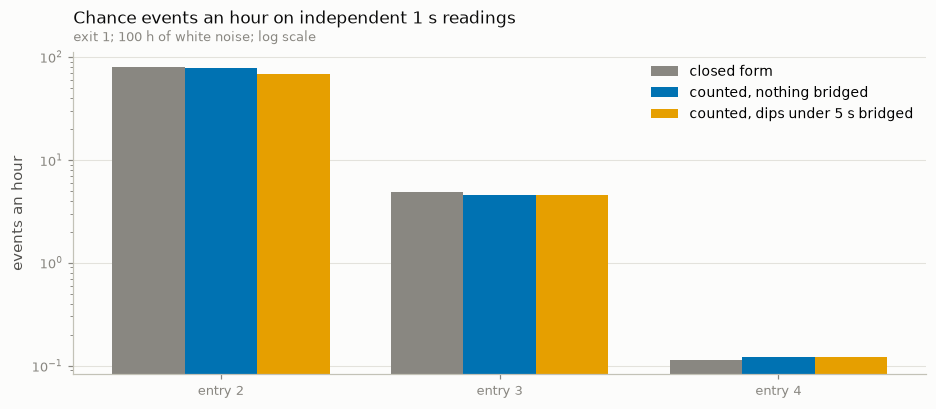

In [14]:
# Figure only: chance events an hour, closed form against the count, by entry multiple.
fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(ENTRIES))
width = 0.26
ax.bar(x - width, [r[1] / HOURS for r in rows], width, color=MUTED, label="closed form")
ax.bar(x, [r[2] / HOURS for r in rows], width, color=C1, label="counted, nothing bridged")
ax.bar(
    x + width,
    [r[3] / HOURS for r in rows],
    width,
    color=C2,
    label="counted, dips under 5 s bridged",
)
ax.set_yscale("log")
ax.set_xticks(x, [f"entry {e:g}" for e in ENTRIES])
finish(
    ax,
    "Chance events an hour on independent 1 s readings",
    f"exit {EXIT:g}; {HOURS:g} h of white noise; log scale",
    "events an hour",
    legend=True,
)
plt.show()

Entry 2 is chance's territory: about 80 events an hour at 1 s, one every 45 s,
which is why the example sweep starts at 3 (about 5 an hour) and goes to 5.
Bridging merges crowded chance crossings, so it lowers entry 2's count by about
a seventh and leaves entry 3's and 4's nearly alone. The rate scales with the
reading rate: a 10 Hz analyzer at entry 2 would make about 800 an hour.

**Try it.**
- `EXIT = 0.0`: the closed form hardly moves (entry 2 from 79.7 to 78.3 an
  hour, entry 3 not at all to two decimals), since on white noise a run that
  reaches entry nearly always reaches it once. Bridging now halves entry 2's
  count, because dips below 0 are short and frequent.
- `HOURS = 10`: the counts scatter more about the closed form, and the checks
  still hold, because they are stated in standard errors.

---
## 5. The window decides what is a plume, and the tree links the scales

**The question.** A baseline at window *w* follows what is slower than about
*w* (`METHODS.md` §6.1), so what counts as a plume depends on the window. The
campaign is §1's: broad landfill plumes (Gaussian, σ 8 min) with short gas
blips on top. The blips stand out at every window. The landfill is subtler.
A low quantile of a window lying on a slope sits below the slope's middle by
about (½ − *q*)·*w*·slope, so at 2 min the baseline follows the landfill but
trails its flanks by several clean spreads: the landfill does not vanish, it
shows as its rising and falling flanks, split at its top, where the slope is
zero. From about 5 min on the baseline stays under the whole plume, and the
landfill is one event holding the blips.

Every window is computed, and the **tree** (`link_parents` in
`src/tsara/plumes/catalog.py`) links each event to the event at the nearest
longer window whose interval holds its peak, skipping a window where nothing
does. So a flank event at 2 min links to the landfill's event at 10 min, which
says what it is: the landfill seen through a short window. The link records
containment, not origin: scale is not source.

The events here come from the **catalog** (`plume_catalog`, same file), one row
per event, variable and sweep point.

In [15]:
# ---- PARAMETERS (section 5) --------------------------------------------------
WINDOWS = ("2min", "10min", "60min")
BLIPS_PER_HOUR = 10.0  # short gas blips an hour, on top of the landfill
SEED = 5

In [16]:
start_section("§5")
campaign = landfill_campaign(seed=SEED, blips_per_hour=BLIPS_PER_HOUR)
state = baseline_state(
    campaign.observable("analyzer"), instrument="analyzer", baseline=sweep(WINDOWS)
)
found = plume_state(state, instrument="analyzer", plumes=thresholds())
catalog = plume_catalog({"analyzer": found}, {"analyzer": state})
truth = campaign.ground_truth.to_frame()
landfill = truth[truth["source_name"] == "landfill"]
blips = truth[(truth["source_name"] == "gas_line") & truth["sampled_peak_amplitude"].notna()]
seconds = [pd.Timedelta(w).total_seconds() for w in WINDOWS]
shortest, longest = min(seconds), max(seconds)
print(catalog.groupby("baseline_window").size().rename("events").to_string())
print(f"true landfill plumes: {len(landfill)}; true gas blips: {len(blips)}")


def holding(rows, when):
    """Return the event_id of the row whose interval holds `when`, or None."""
    hit = rows[(rows["start_time"] <= when) & (when < rows["end_time"])]
    return hit["event_id"].iloc[0] if len(hit) else None


at = {w: catalog[catalog["baseline_window"] == w] for w in seconds}
big_blips = blips[blips["sampled_peak_amplitude"] >= 10 * 0.7]
check(
    "§5 every gas blip of 10 sigma or more is found at the shortest window",
    all(holding(at[shortest], p) for p in big_blips["peak_time"]),
    f"{len(big_blips)} blips",
)
if longest >= 3600:
    check(
        "§5 every landfill plume is found at a window of an hour or more",
        all(holding(at[longest], p) for p in landfill["peak_time"]),
        f"{len(landfill)} plumes",
    )
linked = catalog[catalog["parent_event_id"].notna()]
parents = catalog.set_index("event_id").loc[linked["parent_event_id"]]
check(
    "§5 every parent is at a longer window and holds its child's peak",
    bool(
        (parents["baseline_window"].to_numpy() > linked["baseline_window"].to_numpy()).all()
        and (parents["start_time"].to_numpy() <= linked["peak_time"].to_numpy()).all()
        and (linked["peak_time"].to_numpy() < parents["end_time"].to_numpy()).all()
    ),
    f"{len(linked)} links",
)


def ancestors(event_id):
    """Follow parent links to the top of the tree."""
    chain = [event_id]
    rows = catalog.set_index("event_id")["parent_event_id"]
    while isinstance(rows.get(chain[-1]), str):
        chain.append(rows[chain[-1]])
    return chain


if longest >= 3600:
    # Blips within one landfill sigma (8 min) of a landfill peak sit well inside
    # the landfill's event, so their chains should reach it.
    near = [
        (p, lp)
        for p in big_blips["peak_time"]
        for lp in landfill["peak_time"]
        if abs(p - lp) < pd.Timedelta("8min")
    ]
    check(
        "§5 a blip near a landfill peak links, up the tree, to the event holding that peak",
        all(holding(at[longest], lp) in ancestors(holding(at[shortest], p)) for p, lp in near),
        f"{len(near)} blips",
    )

baseline_window
120.0     57
600.0     43
3600.0    56
true landfill plumes: 4; true gas blips: 69
  ✔ §5 every gas blip of 10 sigma or more is found at the shortest window   [69 blips]
  ✔ §5 every landfill plume is found at a window of an hour or more   [4 plumes]
  ✔ §5 every parent is at a longer window and holds its child's peak   [100 links]
  ✔ §5 a blip near a landfill peak links, up the tree, to the event holding that peak   [13 blips]


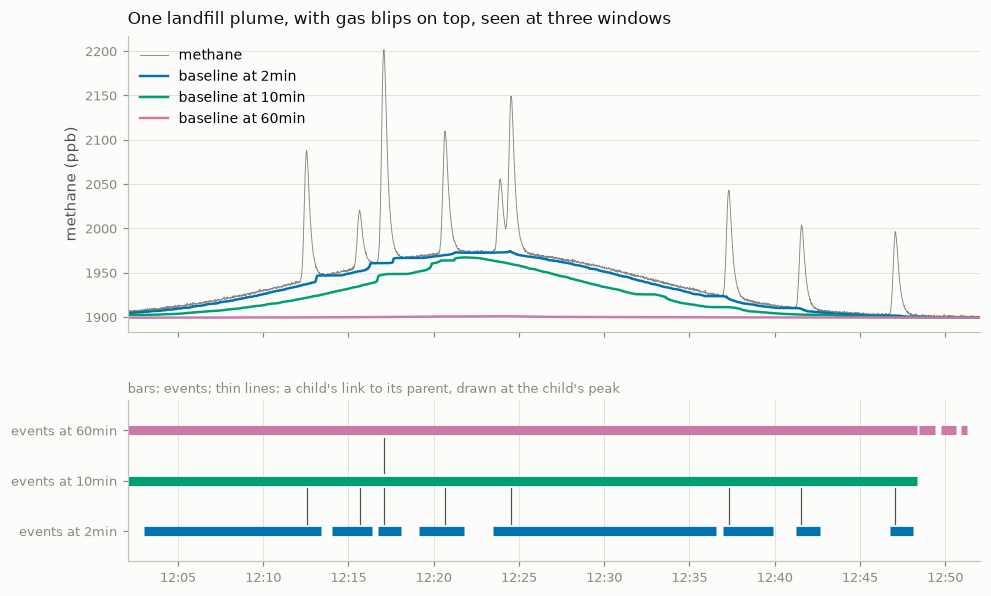

In [17]:
# Figure only: one landfill plume, its blips, the baselines, and the events at each window.
# The largest landfill plume at least 30 min from either end of the record.
first, last = pd.Timestamp(state["time"].values[0]), pd.Timestamp(state["time"].values[-1])
away = landfill[
    (landfill["peak_time"] > first + pd.Timedelta("30min"))
    & (landfill["peak_time"] < last - pd.Timedelta("30min"))
]
peak = away.loc[away["true_amplitude"].idxmax(), "peak_time"]
lo, hi = peak - pd.Timedelta("25min"), peak + pd.Timedelta("25min")
t = state["time"].values
inside = (t >= np.datetime64(lo)) & (t < np.datetime64(hi))
fig, (ax, lad) = plt.subplots(
    2, 1, figsize=(10, 6.2), sharex=True, gridspec_kw={"height_ratios": [2.2, 1.2], "hspace": 0.3}
)
ax.plot(t[inside], state["ch4"].values[inside], color=MUTED, lw=0.6, label="methane")
colours = [C1, C3, C4]
for w, (window, colour) in enumerate(zip(WINDOWS, colours)):
    ax.plot(
        t[inside],
        state["baseline_ch4"].values[inside, w, 0],
        color=colour,
        lw=1.6,
        label=f"baseline at {window}",
    )
finish(
    ax,
    "One landfill plume, with gas blips on top, seen at three windows",
    None,
    "methane (ppb)",
    legend=True,
    loc="upper left",
)
for w, (window, colour) in enumerate(zip(WINDOWS, colours)):
    rows = at[seconds[w]]
    rows = rows[(rows["end_time"] > lo) & (rows["start_time"] < hi)]
    for _, row in rows.iterrows():
        lad.plot(
            [row["start_time"], row["end_time"]], [w, w], color=colour, lw=6, solid_capstyle="butt"
        )
        if isinstance(row["parent_event_id"], str):
            parent = catalog.set_index("event_id").loc[row["parent_event_id"]]
            level = seconds.index(parent["baseline_window"])
            lad.plot([row["peak_time"]] * 2, [w + 0.15, level - 0.15], color=INK2, lw=0.8)
lad.set_yticks(range(len(WINDOWS)), [f"events at {w}" for w in WINDOWS])
lad.set_ylim(-0.6, len(WINDOWS) - 0.4)
lad.set_xlim(lo, hi)
hhmm(lad)
finish(
    lad,
    None,
    "bars: events; thin lines: a child's link to its parent, drawn at the child's peak",
    None,
    grid_axis="x",
)
plt.show()

At 2 min (blue) the baseline climbs with the landfill but a little behind it
on both flanks, so each flank is an event, and the top, where the baseline
catches up, is not. At 10 and 60 min the baseline stays under the plume, and
the landfill is one long event holding every blip. The thin lines are the
tree: each 2 min event links to the 10 min event holding its peak, and that
one to the 60 min event, skipping a window only where nothing holds the peak.
Phase 7 reads this tree to decide which window's ratio belongs to which event
(`METHODS.md` §6.1).

**Try it.**
- `BLIPS_PER_HOUR = 0`: the landfill alone. At 2 min it is its two flanks and
  nothing at its top; at 10 and 60 min it is one event.
- `WINDOWS = ("2min", "60min")`: with the middle window gone, every 2 min event
  inside the plume links straight to the landfill's 60 min event.

---
## 6. The catalog, and scoring it is a join

**The question.** Is every plume found, and how many events are not plumes?
The **catalog** (`plume_catalog` in `src/tsara/plumes/catalog.py`) is one long
table, a row per event, variable and sweep point, keyed by `event_id`. The
columns it shares with the generator's answer key are spelled and typed the
same (`METHODS.md` §6.8), so scoring is `catalog.merge(truth, on=["instrument",
"species"])` and two comparisons: a true plume is **found** when a detected
interval holds its peak time, and a detected event is **false** when its
interval overlaps no true plume at all.

The campaign is the shipped example (`examples/configs/synthetic_example.yaml`):
its 2 s Picarro's methane over 6 h, crossed by a well pad's and a compressor's
plumes. At the defaults below, which are `METHODS.md` §6.8's rule, the last
check compares against the numbers printed there.

In [18]:
# ---- PARAMETERS (section 6) --------------------------------------------------
WINDOWS = ("2min", "10min", "60min")
ENTER = 3.0
EXIT = 1.0
MAX_INTERNAL_GAP = "1ns"  # nothing bridged, as METHODS §6.8 measured; the example config bridges 5s

In [19]:
start_section("§6")
campaign = generate(load_synthetic(CONFIGS / "synthetic_example.yaml"))
state = baseline_state(
    campaign.observable("picarro"), instrument="picarro", baseline=sweep(WINDOWS), variables=["ch4"]
)
config = thresholds((ENTER,), (EXIT,), max_internal_gap=MAX_INTERNAL_GAP)
found = plume_state(state, instrument="picarro", plumes=config)
catalog = plume_catalog({"picarro": found}, {"picarro": state})
hours = np.ptp(state["time"].values).astype("timedelta64[s]").astype(float) / 3600

print(f"{len(catalog)} rows; the first three, a few of the {len(catalog.columns)} columns:")
show = [
    "event_id",
    "parent_event_id",
    "start_time",
    "duration_s",
    "n_readings",
    "peak_enhancement",
    "peak_z",
]
print(catalog[show].head(3).to_string(index=False))

# Scoring: one join, two comparisons.
truth = campaign.ground_truth.to_frame()
truth = truth[truth["sampled_peak_amplitude"].notna()]  # plumes the instrument actually saw
pairs = catalog.merge(truth, on=["instrument", "species"], suffixes=("", "_true"))
holds_peak = (pairs["start_time"] <= pairs["peak_time_true"]) & (
    pairs["peak_time_true"] <= pairs["end_time"]
)
overlaps = (pairs["start_time_true"] <= pairs["end_time"]) & (
    pairs["start_time"] <= pairs["end_time_true"]
)
plumes_seen = truth[(truth["instrument"] == "picarro") & (truth["species"] == "ch4")]
seconds = [pd.Timedelta(w).total_seconds() for w in WINDOWS]
rows = []
print(
    f"\n{'window':>7} {'plumes':>7} {'found':>6} {'events':>7} {'false':>6} {'false /h':>9} "
    f"{'chance /h':>10}"
)
for w, window in enumerate(seconds):
    at = pairs["baseline_window"] == window
    n_found = pairs.loc[at & holds_peak, "event_id_true"].nunique()
    detected = catalog.loc[catalog["baseline_window"] == window, "event_id"]
    false = int((~detected.isin(pairs.loc[at & overlaps, "event_id"])).sum())
    chance = float(found["chance_events_ch4"].values[w, 0, 0, 0]) / hours
    rows.append((n_found, false / hours))
    print(
        f"{WINDOWS[w]:>7} {len(plumes_seen):>7} {n_found:>6} {len(detected):>7} {false:>6} "
        f"{false / hours:>9.2f} {chance:>10.2f}"
    )

shared = [c for c in CATALOG_COLUMNS if c in GROUND_TRUTH_COLUMNS]
check(
    "§6 every column the catalog shares with the answer key has its name and its type",
    all(catalog[c].dtype == truth[c].dtype for c in shared),
    f"{len(shared)} columns",
)
check(
    "§6 every event_id is unique and names its instrument, variable and sweep point",
    catalog["event_id"].is_unique
    and all(
        e.startswith(f"{i}.{s}/w{b:g}s/q{q:g}/e{n:g}/x{x:g}/")
        for e, i, s, b, q, n, x in zip(
            catalog["event_id"],
            catalog["instrument"],
            catalog["species"],
            catalog["baseline_window"],
            catalog["baseline_quantile"],
            catalog["enter_multiple"],
            catalog["exit_multiple"],
        )
    ),
)
check(
    "§6 every row's interval holds its peak, and covers between none and all of itself",
    bool(
        (
            (catalog["start_time"] <= catalog["peak_time"])
            & (catalog["peak_time"] < catalog["end_time"])
        ).all()
        and ((catalog["covered"] > 0) & (catalog["covered"] <= 1)).all()
    ),
)
check(
    "§6 the catalog holds, per sweep point, the events the plume state counted",
    [int((catalog["baseline_window"] == s).sum()) for s in seconds]
    == [int(n) for n in found["n_events_ch4"].values[:, 0, 0, 0]],
)
# A false event is chance, not a missed plume: the answer key's plume at its peak.
reading = campaign.streams["picarro"]
peaks = np.searchsorted(reading["time"].values, catalog["peak_time"].to_numpy())
plume_at_peak = reading["truth_enhancement_ch4"].values[
    np.minimum(peaks, reading.sizes["time"] - 1)
]
false_rows = ~catalog["event_id"].isin(pairs.loc[overlaps, "event_id"]).to_numpy()
check(
    "§6 no false event has a true plume above the Picarro's 0.6 ppb noise at its peak",
    bool((plume_at_peak[false_rows] < 0.6).all()),
    f"{int(false_rows.sum())} false events",
)

# Where plume-free air sits against the baseline, half hour by half hour, at the
# longest window: the true background minus the baseline, relative to its median
# over the record (which also removes the Picarro's systematic offset), in spreads.
longest = len(WINDOWS) - 1
under = reading["truth_background_ch4"].values - state["baseline_ch4"].values[:, longest, 0]
spread = float(found["clean_spread_ch4"].values[0, longest, 0])
by_half_hour = (
    pd.Series((under - np.nanmedian(under)) / spread)
    .groupby(pd.DatetimeIndex(reading["time"].values).floor("30min"))
    .mean()
)
print(
    f"\nat {WINDOWS[longest]}, plume-free air against the baseline, per half hour, "
    f"in clean spreads: {' '.join(f'{v:+.1f}' for v in by_half_hour)}"
)
high = by_half_hour.index[by_half_hour > 1.0]
at_longest = (catalog["baseline_window"] == seconds[longest]).to_numpy() & false_rows
in_high = pd.DatetimeIndex(catalog.loc[at_longest, "peak_time"]).floor("30min").isin(high)
print(
    f"false events at {WINDOWS[longest]}: {int(at_longest.sum())}, of which {int(in_high.sum())} "
    f"in the {len(high)} half hours where that air sits over one spread high"
)
at_rule = (WINDOWS, ENTER, EXIT, MAX_INTERNAL_GAP) == (("2min", "10min", "60min"), 3.0, 1.0, "1ns")
if at_rule:
    check(
        "§6 at METHODS §6.8's rule: all 59 plumes found at every window; "
        "false 2.50, 4.00, 7.67 an hour",
        [r[0] for r in rows] == [59, 59, 59]
        and [round(r[1], 2) for r in rows] == [2.50, 4.00, 7.67],
    )

213 rows; the first three, a few of the 28 columns:
                       event_id                 parent_event_id          start_time  duration_s  n_readings  peak_enhancement    peak_z
picarro.ch4/w120s/q0.05/e3/x1/0 picarro.ch4/w600s/q0.05/e3/x1/0 2026-06-15 14:02:17       156.0          78         51.437756 83.725783
picarro.ch4/w120s/q0.05/e3/x1/1 picarro.ch4/w600s/q0.05/e3/x1/1 2026-06-15 14:05:31       140.0          70         22.429949 35.662673
picarro.ch4/w120s/q0.05/e3/x1/2 picarro.ch4/w600s/q0.05/e3/x1/2 2026-06-15 14:13:15         4.0           2          2.991198  3.454555

 window  plumes  found  events  false  false /h  chance /h
   2min      59     59      65     15      2.50       2.43
  10min      59     59      67     24      4.00       2.43
  60min      59     59      81     46      7.67       2.43
  ✔ §6 every column the catalog shares with the answer key has its name and its type   [10 columns]
  ✔ §6 every event_id is unique and names its instrument, variable 

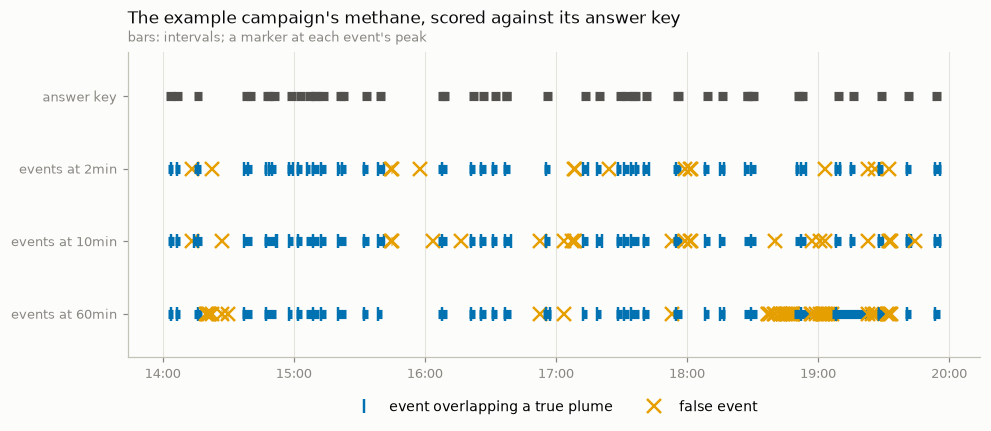

In [20]:
# Figure only: the answer key above, and each window's events below, over the whole record.
fig, ax = plt.subplots(figsize=(10, 3.6))
for _, plume in plumes_seen.iterrows():
    ax.hlines(len(WINDOWS), plume["start_time"], plume["end_time"], color=INK2, lw=6)
for w, window in enumerate(seconds):
    at = pairs["baseline_window"] == window
    touching = set(pairs.loc[at & overlaps, "event_id"])
    level = len(WINDOWS) - 1 - w
    for _, event in catalog[catalog["baseline_window"] == window].iterrows():
        real = event["event_id"] in touching
        colour, marker = (C1, "|") if real else (C2, "x")
        ax.hlines(level, event["start_time"], event["end_time"], color=colour, lw=6)
        ax.plot(event["peak_time"], level, marker, color=colour, ms=9, mew=1.6)
ax.plot([], [], "|", color=C1, ms=9, mew=1.6, label="event overlapping a true plume")
ax.plot([], [], "x", color=C2, ms=9, mew=1.6, label="false event")
ax.set_yticks(range(len(WINDOWS) + 1), [f"events at {w}" for w in WINDOWS[::-1]] + ["answer key"])
ax.set_ylim(-0.6, len(WINDOWS) + 0.6)
hhmm(ax)
finish(
    ax,
    "The example campaign's methane, scored against its answer key",
    "bars: intervals; a marker at each event's peak",
    None,
    grid_axis="x",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.show()

Every plume in the answer key is found at every window. The false events are
chance crossings, not missed plumes: none has a true plume above the noise at
its peak, and their peaks sit just past the entry line. How many there are
scatters about the chance column (§4's closed form, for this record's 2 s
readings) for two measured reasons. The clean spread is estimated from one
record, and the chance rate is steep in it: a spread 5 % low lets 1.6 times as
many crossings through at entry 3, one 5 % high 0.6 times (`METHODS.md` §6.8
records the scatter over seeds). And at 60 min the baseline no longer follows
the background's slow wander, so in some half hours plume-free air sits higher
against it than the record's one clean level expects. The printed lines show
where: 32 of the 46 false events at 60 min fall in the two half hours where
that air sits over a spread high, a sixth of the record (18:30 to 19:30 in the
figure). Nothing is deleted: the chance column says how many to expect from
noise alone.

**Try it.**
- `ENTER = 5.0`: no false event at any window, and every plume is still found;
  the example's plumes are large.
- `MAX_INTERNAL_GAP = "5s"`, the example config's value: dips shorter than 5 s
  are bridged, which merges fragments. Fewer events, the same plumes found, and
  at 60 min the crowded crossings of those two half hours merge: 46 false events
  become 6.

---
## 7. A sparse canister takes its events from a dense analyzer

**The question.** A whole-air canister is filled for 15 s every few minutes, so
over a 6 h record it holds tens of readings, too few to measure its own
plume-free air: a record with fewer than `min_clean_readings` (default 100)
readings below its level is **blank**, with the reason, and finds no events of
its own. It still needs to know which fills were taken in a plume. So it takes
its events from a dense instrument named in `triggers` (`METHODS.md` §6.8): each
of the trigger's event intervals becomes the canister's, and a fill belongs to
it when the fill's cell midpoint lies in [start, end). The trigger may measure
any field; here a 1 s benzene analyzer triggers the canister's benzene.

The canister's baseline is a declared constant of zero, so its enhancement is
its reading (notebook 05 §6); a trigger's intervals do not depend on that
choice.

In [21]:
# ---- PARAMETERS (section 7) --------------------------------------------------
FILL_EVERY = "300s"  # a canister is filled about this often, 15 s each
PLUMES_PER_HOUR = 3.0  # refinery plumes an hour (Gaussian, sigma 3 min)
WINDOW = "10min"
SEED = 21

In [22]:
start_section("§7")
campaign = canister_campaign(seed=SEED, fill_every=FILL_EVERY, plumes_per_hour=PLUMES_PER_HOUR)
settings = sweep((WINDOW,), methods={"iwas.benzene_can": {"method": "constant", "value": 0.0}})
baselines = {
    name: baseline_state(campaign.observable(name), instrument=name, baseline=settings)
    for name in ("ptr", "iwas")
}

# On its own: the canister describes its air only where enough fills lie below its level.
alone = plume_states(baselines, thresholds())
level = alone["iwas"]["clean_level_benzene_can"].values
below = alone["iwas"]["n_clean_readings_benzene_can"].values
fills = int(np.isfinite(baselines["iwas"]["benzene_can"].values).sum())
print(f"canister fills: {fills}; the most below its clean level in a record: {int(below.max())}")
check(
    "§7 a record has a clean level exactly where at least min_clean_readings readings lie below it",
    np.array_equal(np.isnan(level), below < 100),
)

# With a trigger: the analyzer's intervals, the canister's own fills.
triggered = plume_states(baselines, thresholds(triggers={"iwas": "ptr.benzene"}))
catalog = plume_catalog(triggered, baselines)
canister = catalog[catalog["instrument"] == "iwas"]
analyzer = catalog[catalog["instrument"] == "ptr"].set_index("event_id")
their = analyzer.loc[canister["trigger_event_id"]]
midpoints = baselines["iwas"]["time"].values  # every stream's time is its cell midpoint
counted = [
    int(((midpoints >= a) & (midpoints < b)).sum())
    for a, b in zip(canister["start_time"], canister["end_time"])
]
print(f"analyzer events: {len(analyzer)}; canister rows: {len(canister)}")
check(
    "§7 every canister event is its trigger's interval exactly",
    bool(
        (canister["start_time"].to_numpy() == their["start_time"].to_numpy()).all()
        and (canister["end_time"].to_numpy() == their["end_time"].to_numpy()).all()
    ),
)
check(
    "§7 each canister event holds exactly the fills whose midpoints lie in [start, end)",
    canister["n_readings"].tolist() == counted,
)
holding = {
    event_id
    for event_id, a, b in zip(analyzer.index, analyzer["start_time"], analyzer["end_time"])
    if ((midpoints >= a) & (midpoints < b)).any()
}
check(
    "§7 the canister has a row for exactly the analyzer's events that hold one of its fills",
    set(canister["trigger_event_id"]) == holding,
    f"{len(holding)} of {len(analyzer)}",
)

# What the trigger buys: fills taken inside a true plume are in an event, clean fills mostly not.
truth = campaign.streams["iwas"]["truth_enhancement_benzene_can"].values
in_event = triggered["iwas"]["event_benzene_can"].values[:, 0, 0, 0, 0] >= 0
plumy, clean = truth > 0.2, truth < 0.02
print(
    f"fills in a true plume above 0.2 ppb: {plumy.sum()}, "
    f"in an event {in_event[plumy].mean():.0%}; "
    f"clean fills (under 0.02 ppb): {clean.sum()}, in an event {in_event[clean].mean():.0%}"
)
check(
    "§7 a fill in a plume above 0.2 ppb is more often in an event than a clean fill",
    plumy.sum() == 0 or clean.sum() == 0 or in_event[plumy].mean() > in_event[clean].mean(),
)

2026-09-30 15:21:55 | WARNING  | tsara.plumes.state | Plume state of 'iwas': sweep points at which every record is blank, so no event is found -- benzene_can: 600 s, q 0.05 (at most 16). A record needs 100 readings below its clean level (METHODS 6.8); a sparse variable can take its events from a dense one named in plumes.triggers.


canister fills: 72; the most below its clean level in a record: 16
  ✔ §7 a record has a clean level exactly where at least min_clean_readings readings lie below it
analyzer events: 13; canister rows: 13
  ✔ §7 every canister event is its trigger's interval exactly
  ✔ §7 each canister event holds exactly the fills whose midpoints lie in [start, end)
  ✔ §7 the canister has a row for exactly the analyzer's events that hold one of its fills   [13 of 13]
fills in a true plume above 0.2 ppb: 32, in an event 100%; clean fills (under 0.02 ppb): 32, in an event 0%
  ✔ §7 a fill in a plume above 0.2 ppb is more often in an event than a clean fill


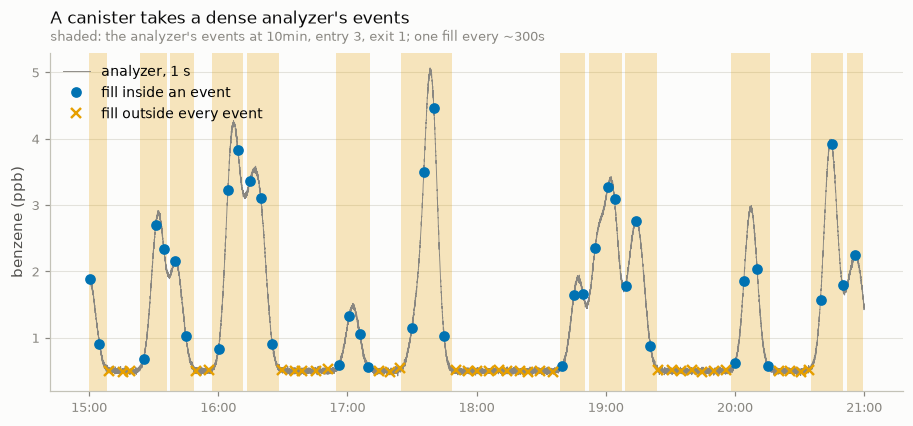

In [23]:
# Figure only: the analyzer's benzene, its events shaded, and the canister's fills on top.
ptr = baselines["ptr"]
t = ptr["time"].values
fig, ax = plt.subplots(figsize=(10, 4.0))
events = triggered["ptr"]["event_benzene"].values[:, 0, 0, 0, 0]
shade_events(ax, stream_cells(ptr, "ptr"), events)
ax.plot(t, ptr["benzene"].values, color=MUTED, lw=0.6, label="analyzer, 1 s")
can = baselines["iwas"]
value = can["benzene_can"].values
ax.plot(
    can["time"].values[in_event], value[in_event], "o", color=C1, ms=6, label="fill inside an event"
)
ax.plot(
    can["time"].values[~in_event],
    value[~in_event],
    "x",
    color=C2,
    ms=6,
    mew=1.6,
    label="fill outside every event",
)
hhmm(ax)
finish(
    ax,
    "A canister takes a dense analyzer's events",
    f"shaded: the analyzer's events at {WINDOW}, entry 3, exit 1; one fill every ~{FILL_EVERY}",
    "benzene (ppb)",
    legend=True,
    loc="upper left",
)
plt.show()

The analyzer finds the plumes, and each shaded interval that holds a fill is
also a canister event, with that fill in it. A plume no fill caught stays in the
analyzer's rows and not the canister's, and the canister's `n_events` counts
only the analyzer's events holding one of its fills. The canister's own
`clean_level`, `peak_z` and chance columns are blank in the catalog, since it
measured no air of its own, and its `trigger_event_id` names the analyzer's row,
so the two stay linked.

**Try it.**
- `FILL_EVERY = "1800s"`: a fill every half hour, so some plumes pass between
  fills; the canister has fewer rows than the analyzer has events.
- `FILL_EVERY = "30s"`: over 700 fills, so the canister's record now has enough
  below its level, and on its own it describes its air (the first print line).
  With the trigger named it still takes the analyzer's events: a trigger is a
  choice, not a fallback.
- `PLUMES_PER_HOUR = 0.5`: few plumes, so most fills are clean and outside
  every event. Most of the analyzer's events are now chance crossings (about
  five an hour at 1 s, §4), short enough that a fill rarely falls in one.

---
## 8. The state and the catalog save, and reload exactly

**The question.** A plume state is the input to Phase 7, so it must survive a
save and a reload without losing a bit, and so must the catalog beside it.
`save_plumes` writes one netCDF file per instrument into the bundle's `plumes/`
directory, the catalog as Parquet beside them, and the plumes configuration as
the `plumes` section of an `analysis.yaml`; `load_plumes` brings all three back
(`src/tsara/plumes/bundle.py`). The chain here is §7's, shortened to two hours:
an analyzer that finds its own events and a canister that takes them, so that
both kinds of variable make the round trip.

In [24]:
# ---- PARAMETERS (section 8) --------------------------------------------------
COMPRESSION = 4  # zlib level for the second save, 1 to 9, or None

In [25]:
start_section("§8")
campaign = canister_campaign(duration="2h")
settings = sweep(
    ("2min", "10min"), methods={"iwas.benzene_can": {"method": "constant", "value": 0.0}}
)
baselines = {
    name: baseline_state(campaign.observable(name), instrument=name, baseline=settings)
    for name in ("ptr", "iwas")
}
config = thresholds((3.0, 4.0), (1.0,), triggers={"iwas": "ptr.benzene"})
states = plume_states(baselines, config)
catalog = plume_catalog(states, baselines)

plain = save_plumes(states, WORK / "plain", catalog=catalog, plumes=config)
small = save_plumes(states, WORK / "small", catalog=catalog, plumes=config, compression=COMPRESSION)
back = load_plumes(WORK / "plain")
second = "uncompressed" if COMPRESSION is None else f"at zlib level {COMPRESSION}"
for path in sorted(plain.iterdir()):
    print(
        f"  plumes/{path.name:18s} {path.stat().st_size / 1e3:8.1f} kB plain, "
        f"{(small / path.name).stat().st_size / 1e3:8.1f} kB {second}"
    )


def identical(a, b):
    """Every variable and coordinate exactly, every attribute exactly, arrays included."""
    if sorted(map(str, a.variables)) != sorted(map(str, b.variables)):
        return False
    for name in a.variables:
        if a[name].dims != b[name].dims or a[name].dtype != b[name].dtype:
            return False
        if not same(a[name].values, b[name].values):
            return False
        for key, value in a[name].attrs.items():
            if name == "time" and key == "bounds":
                continue  # moved into encoding on load, by xarray's CF decoding
            other = b[name].attrs.get(key)
            if isinstance(value, np.ndarray):
                if not np.array_equal(value, other):
                    return False
            elif value != other:
                return False
    return a.attrs == b.attrs


def frames_equal(a, b):
    """Two catalogs with the same columns, types and values, blanks included."""
    try:
        pd.testing.assert_frame_equal(a, b, check_exact=True)
    except AssertionError:
        return False
    return True


check(
    "§8 every reloaded plume state is the saved one, every variable and attribute exactly",
    all(identical(states[name], back.states[name]) for name in states),
)
check(
    "§8 the compressed bundle reloads to the same states",
    all(identical(back.states[name], load_plumes(WORK / "small").states[name]) for name in states),
)
check(
    "§8 the reloaded catalog is the saved one: columns, types and values",
    frames_equal(back.catalog, catalog),
)
check(
    "§8 the catalog built again from the reloaded states is the saved one",
    frames_equal(plume_catalog(back.states, baselines), catalog),
)
check("§8 the plumes configuration comes back beside them", back.plumes == config)

  plumes/analysis.yaml           0.2 kB plain,      0.2 kB at zlib level 4
  plumes/catalog.parquet        19.2 kB plain,     19.2 kB at zlib level 4
  plumes/iwas.nc                20.5 kB plain,     42.0 kB at zlib level 4
  plumes/ptr.nc                745.4 kB plain,    176.2 kB at zlib level 4
  ✔ §8 every reloaded plume state is the saved one, every variable and attribute exactly
  ✔ §8 the compressed bundle reloads to the same states
  ✔ §8 the reloaded catalog is the saved one: columns, types and values
  ✔ §8 the catalog built again from the reloaded states is the saved one
  ✔ §8 the plumes configuration comes back beside them


**What to read off the output.** The round trip loses nothing: values, the
cells, the event index at every sweep point, and the attributes that name each
canister variable's trigger. The catalog built again from the reloaded states
equals the saved one, so the catalog is a view of the states and can always be
rebuilt. Compression is a choice at save time and changes only the size: the
analyzer's event index is mostly −1, and its file shrinks about four times,
while the canister's file, a few dozen readings, grows, because compressed
storage is written in chunks that each carry some overhead. Worth it for long
records, not for tiny ones.

**Try it.** `COMPRESSION = None`: the second bundle is as large as the first,
and it still reloads to the same states.

---
## 9. Scoreboard, and what is known to be imperfect

Every check in this notebook, as it ran. Then the limits this phase records
rather than resolves.

In [26]:
held = sum(1 for ok, _ in CHECKS.values() if ok)
print(f"{held} of {len(CHECKS)} checks hold\n")
for claim, (ok, detail) in CHECKS.items():
    print(f"  {'✔' if ok else '✘'} {claim}" + (f"   [{detail}]" if detail else ""))

34 of 34 checks hold

  ✔ §1 the clean level is the half-sample mode, as the paper defines it
  ✔ §1 the clean spread is 1.4826 x the median distance below it
  ✔ §1 the clean level lies within one true spread of truly plume-free air   [+0.14 true spreads]
  ✔ §1 the clean spread is within a factor of two of the true one   [1.07]
  ✔ §2 every reading's record is the definition's, reading by reading
  ✔ §2 no record is longer than the maximum length
  ✔ §2 no record spans a gap longer than the record gap
  ✔ §2 the dropouts are the definition's: steps within a record over 1.5 x its median step   [1 found]
  ✔ §3 every reading's event is the one a loop over the definition finds
  ✔ §3 every event holds a reading at or above entry
  ✔ §3 a reading below exit is in an event only inside a dip shorter than the gap
  ✔ §4 the package's closed form is the one written out from the definition
  ✔ §4 on white noise the count agrees with the closed form within five Poisson standard errors
  ✔ §4 b

### Known to be imperfect, and where each is written down

* **On a plume-dense record the description of clean air errs, and chance
  events multiply.** On §3's three hours, two-thirds plume, plume-free air
  reaches entry nine times as often as the closed form expects at 2 min, and
  never at 10 min. The clean spread is estimated from one record, and a spread
  5 % low lets 1.6 times as many chance crossings through at entry 3 (§6). On 12 h of generated air the half-sample mode's
  false events vary by 4 to 12 an hour from seed to seed (`METHODS.md` §6.8);
  a steadier estimator is recorded as an open question, registered by name so
  that it would be a drop-in.
* **The chance column assumes independent Gaussian readings.** It is an upper
  bound once dips are bridged (§4), and it says nothing about air that wanders
  faster than a window follows, which crosses more often (§6).
* **The clean spread is not a measurement uncertainty.** It holds the
  background's wobble at the window's scale as well as the instrument's noise,
  and it is never used as a sigma (`METHODS.md` §2.3, §6.8). What "noise" means
  on a moving platform, where the air changes along the road, is open (§2.5).
* **A record's cuts are arbitrary.** A stream that logs for longer than
  `max_record_length` is cut into equal parts, and an event running across a
  cut is two events, one in each record (§2; `METHODS.md` §6.8).
* **Scale is not source.** At a short window a broad plume shows as its two
  flanks (§5), and a cluster of short plumes lifts a short window's baseline
  as one long plume would (notebook 05 §2). The tree records which event holds
  which; which window's ratio belongs to which event is Phase 7's
  (`METHODS.md` §6.1).
* **A canister's events are its trigger's.** A plume no fill caught is not in
  its rows, and an adopted baseline carries the donor's noise offset into its
  enhancement's values, a question for receptor rows (§7; `METHODS.md` §6.5).